### Dask Dashboard

In [1]:
from dask.distributed import Client, LocalCluster

# --- Dask Configuration Summary ---
# [Dask Worker](https://distributed.dask.org/en/stable/worker.html)

# Default strategy: sqrt(total_cores)
# Example (16 cores): n_workers=4, threads_per_worker=4

# 1. CPU-bound (Pure Python): Increase n_workers (processes) to bypass GIL.
# 2. I/O-bound / Numeric (NumPy/Pandas): Increase threads_per_worker to share memory.

# General Rule (Balanced): 
# n_workers = int(total_cores**0.5)
# threads_per_worker = total_cores // n_workers

### localCluster: 代表在本地端使用 Dask ，它會在你的電腦上啟動多個 workers (processes) 進行計算
cluster = LocalCluster(
    n_workers=4,            # Number of processes
    threads_per_worker=8,   # Threads per process
    dashboard_address=":8888",
)

client = Client(cluster)
print(f"Dask Dashboard: {client.dashboard_link}")
client

Dask Dashboard: http://127.0.0.1:8888/status


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8888/status,
Dashboard: http://127.0.0.1:8888/status,Workers: 4
Total threads: 32,Total memory: 78.45 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44901,Workers: 0
Dashboard: http://127.0.0.1:8888/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34727,Total threads: 8
Dashboard: http://127.0.0.1:44011/status,Memory: 19.61 GiB
Nanny: tcp://127.0.0.1:40927,


### Zarr、COG 格式轉換

#### 轉成zarr

In [16]:
import xarray as xr
import rioxarray
import os

def convert_tif_to_zarr(input_tif, output_zarr, chunk_size=256):
    """
    將 GeoTIFF 轉換為 Zarr 格式，並指定空間區塊 (Chunk) 大小。
    """
    print(f"⏳ 正在讀取 {os.path.basename(input_tif)} ...")
    
    # 1. 使用 rioxarray 讀取 GeoTIFF
    # 這裡直接在讀取時指定 chunks，可以避免大檔案造成記憶體不足 (OOM)
    da = rioxarray.open_rasterio(
        input_tif, 
        chunks={'x': chunk_size, 'y': chunk_size}
    )
    
    # 2. 確保維度的 Chunk 正確對齊
    # 衛星影像通常有 'band', 'y', 'x' 三個維度。
    # WebGIS 應用通常是一次讀取所有波段，所以 band 的 chunk 設為 -1 (不切塊)，x 和 y 根據參數切塊。
    da = da.chunk({'band': -1, 'x': chunk_size, 'y': chunk_size})
    
    print(f"📦 開始轉換並輸出 Zarr (Chunk: {chunk_size}x{chunk_size}) ...")
    
    # 3. 輸出為 Zarr 格式
    # mode='w' 表示如果目標資料夾已存在則覆蓋
    # consolidated=True 會將 metadata 集中在一個檔案，這對雲端或網路讀取速度(WebGIS)非常重要！
    da.to_zarr(
        output_zarr, 
        zarr_format=3, 
        mode='w', 
        consolidated=True)
    
    print(f"✅ 成功產出：{output_zarr}\n")

# ==========================================
# 🧪 測試你的實驗設定
# ==========================================
input_file = "/home/chunen/nas/bigdata/final/S2_aoi_test/Orig_445_20200627T092658.tif"

# 產出 256 Chunk 的 Zarr
zarr_256_out = "/home/chunen/nas/bigdata/final/S2_aoi_test_zarr/256chunk_445_20200627T092658.zarr"
convert_tif_to_zarr(input_file, zarr_256_out, chunk_size=256)

# 產出 512 Chunk 的 Zarr
zarr_512_out = "/home/chunen/nas/bigdata/final/S2_aoi_test_zarr/512chunk_445_20200627T092658.zarr"
convert_tif_to_zarr(input_file, zarr_512_out, chunk_size=512)

⏳ 正在讀取 Orig_445_20200627T092658.tif ...
📦 開始轉換並輸出 Zarr (Chunk: 256x256) ...


/home/chunen/course_BigData/.venv/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


✅ 成功產出：/home/chunen/nas/bigdata/final/S2_aoi_test_zarr/256chunk_445_20200627T092658.zarr

⏳ 正在讀取 Orig_445_20200627T092658.tif ...
📦 開始轉換並輸出 Zarr (Chunk: 512x512) ...


/home/chunen/course_BigData/.venv/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


✅ 成功產出：/home/chunen/nas/bigdata/final/S2_aoi_test_zarr/512chunk_445_20200627T092658.zarr



#### 檢查是否為COG

In [3]:
from rio_cogeo.cogeo import cog_validate

file_path = "/home/chunen/nas/bigdata/final/DW_test/dw_kurosiwo_445_annual-20190627-20200626_probs.tif"

# rio_cogeo 檢查，但由於 GEE 預設輸出的格式就已經具備了 COG 的雛形，因此即使沒有 "cloudOptimized": True ，也會被判定COG
is_valid, errors, warnings = cog_validate(file_path)

if is_valid:
    print(f"✅ {file_path} 是一個標準的 COG 檔案！")
else:
    print(f"❌ 驗證失敗：")
    for error in errors:
        print(f"  - Error: {error}")
    for warning in warnings:
        print(f"  - Warning: {warning}")

# rasterio 檢查 Overviews
import rasterio
with rasterio.open(file_path) as src:
    print(f"Overviews 數量: {src.overviews(1)}")

✅ /home/chunen/nas/bigdata/final/DW_test/dw_kurosiwo_445_annual-20190627-20200626_probs.tif 是一個標準的 COG 檔案！
Overviews 數量: [2]


#### 轉檔（change COG tiles）

In [2]:
from rio_cogeo.cogeo import cog_translate
from rio_cogeo.profiles import cog_profiles
import rasterio
import os

def make_cog_variants(input_tif, out_dir):

    configs = [
        {"name": "256_deflate", "block": 256, "compress": "DEFLATE"},
        {"name": "512_deflate", "block": 512, "compress": "DEFLATE"},
    ]

    base_name = os.path.basename(input_tif)

    for cfg in configs:

        profile = cog_profiles.get("deflate")

        profile.update({
            "blockxsize": cfg["block"],
            "blockysize": cfg["block"],
            "compress": cfg["compress"]
        })

        output = os.path.join(out_dir, f"{cfg['name']}_{base_name}")

        with rasterio.open(input_tif) as src:
            cog_translate(
                src,
                output,
                profile,
                overview_resampling="average",
                config={"GDAL_TIFF_OVR_BLOCKSIZE": str(cfg["block"])}
            )

        print(f"Created {output}")

In [7]:
import dask
from dask import delayed
import os

s2_dir = "/home/chunen/nas/bigdata/final/DW_test"
out_dir = "/home/chunen/nas/bigdata/final/DW_test"
target_name = 'dw_kurosiwo_502'

# 建立 Dask 延遲任務，並保留資料夾結構
tasks = []
tif_count = 0

for root, dirs, files in os.walk(s2_dir):
    for file in files:
        if file.lower().endswith('.tif') and file.startswith(target_name):
            input_tif = os.path.join(root, file)
            # 計算該檔案相對於 S2 資料夾的相對路徑
            rel_path = os.path.relpath(root, s2_dir)
            # 在 S2_modify 下建立相對應的子目錄
            out_dir_sub = os.path.normpath(os.path.join(out_dir, rel_path))
            os.makedirs(out_dir_sub, exist_ok=True)
            
            tasks.append(delayed(make_cog_variants)(input_tif, out_dir_sub))
            tif_count += 1

print(f"找到 {tif_count} 個 tif 檔案，開始以 dask 進行平行轉換...")
# Client 已經啟動，此處的 compute 會自動推送到背景 Dask cluster 執行平行運算
dask.compute(*tasks)
print("轉換完成！")

找到 1 個 tif 檔案，開始以 dask 進行平行轉換...


Reading input: <open DatasetReader name='/home/chunen/nas/bigdata/final/DW_test/dw_kurosiwo_502_annual-20200224-20210223_probs.tif' mode='r'>

Adding overviews...
Updating dataset tags...
Writing output to: /home/chunen/nas/bigdata/final/DW_test/256_deflate_dw_kurosiwo_502_annual-20200224-20210223_probs.tif


Created /home/chunen/nas/bigdata/final/DW_test/256_deflate_dw_kurosiwo_502_annual-20200224-20210223_probs.tif


Reading input: <open DatasetReader name='/home/chunen/nas/bigdata/final/DW_test/dw_kurosiwo_502_annual-20200224-20210223_probs.tif' mode='r'>

Updating dataset tags...
Writing output to: /home/chunen/nas/bigdata/final/DW_test/512_deflate_dw_kurosiwo_502_annual-20200224-20210223_probs.tif


Created /home/chunen/nas/bigdata/final/DW_test/512_deflate_dw_kurosiwo_502_annual-20200224-20210223_probs.tif
轉換完成！


#### 轉檔（COG to normal geotiff）

In [11]:
import rasterio

input_cog = "/home/chunen/nas/bigdata/final/DW_test/dw_kurosiwo_502_annual-20200224-20210223_probs.tif"
output_standard_tif = "/home/chunen/nas/bigdata/final/DW_test/Orig_dw_kurosiwo_502_annual-20200224-20210223_probs.tif"

# 打開你的 COG 檔案
with rasterio.open(input_cog) as src:
    # 複製原始的 metadata (包含 CRS, 座標轉換矩陣, 波段數等)
    profile = src.profile
    
    # 關閉 COG 的核心特性：取消區塊化 (Tiled)，而 overview 也會跟著消失
    # 這會讓 GeoTIFF 回到傳統的條帶狀 (Striped) 儲存方式
    profile.update(
        tiled=False,
        compress=None  # 🌟 手動取消壓縮
    )
    
    # 你也可以選擇移除 blockxsize 和 blockysize (如果原本有的話)
    profile.pop('blockxsize', None)
    profile.pop('blockysize', None)

    # 讀取所有的像素資料
    data = src.read()

    # 以新的設定寫出檔案
    with rasterio.open(output_standard_tif, 'w', **profile) as dst:
        dst.write(data)

print(f"轉換完成！存到 {output_standard_tif}")

轉換完成！存到 /home/chunen/nas/bigdata/final/DW_test/Orig_dw_kurosiwo_502_annual-20200224-20210223_probs.tif


### S2評估

#### COG Tiling Comparison

🚀 開始模擬 WebGIS 隨機存取測試 (比較 Default vs 256 vs 512)...



✅ 測試完成: 502_5_20210224T114659.tif
✅ 測試完成: 470_20201015T102803.tif
✅ 測試完成: 445_20200627T092658.tif

📊 效能比較結果：
                 Image_ID  Orig Size (KB)  Default Size (KB)  256 Size (KB)  512 Size (KB)  Orig Latency (s)  Default Latency (s)  256 Latency (s)  512 Latency (s)  Orig CPU (%)  Default CPU (%)  256 CPU (%)  512 CPU (%)  Orig Mem (MB)  Default Mem (MB)  256 Mem (MB)  512 Mem (MB)  Orig Throughput (req/s)  Default Throughput (req/s)  256 Throughput (req/s)  512 Throughput (req/s)  Winner
502_5_20210224T114659.tif       324959.68          245671.12      158358.16      160379.64             0.330                0.131            0.132            0.172        2173.2           1466.0        870.4       1397.0         2126.9            1861.0        1864.6        1941.4                  303.279                     764.058                 758.657                 582.026 Default
  470_20201015T102803.tif      1098317.64         1306196.25     1069243.43     1082722.75             0.285 

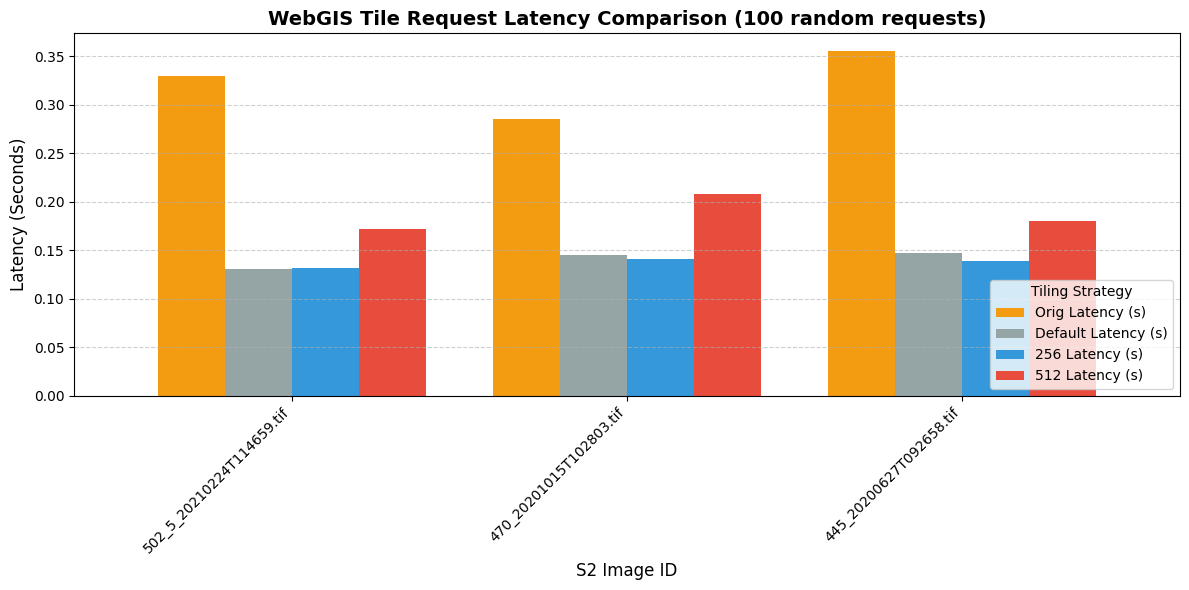


🎨 正在生成檔案容量柱狀圖...


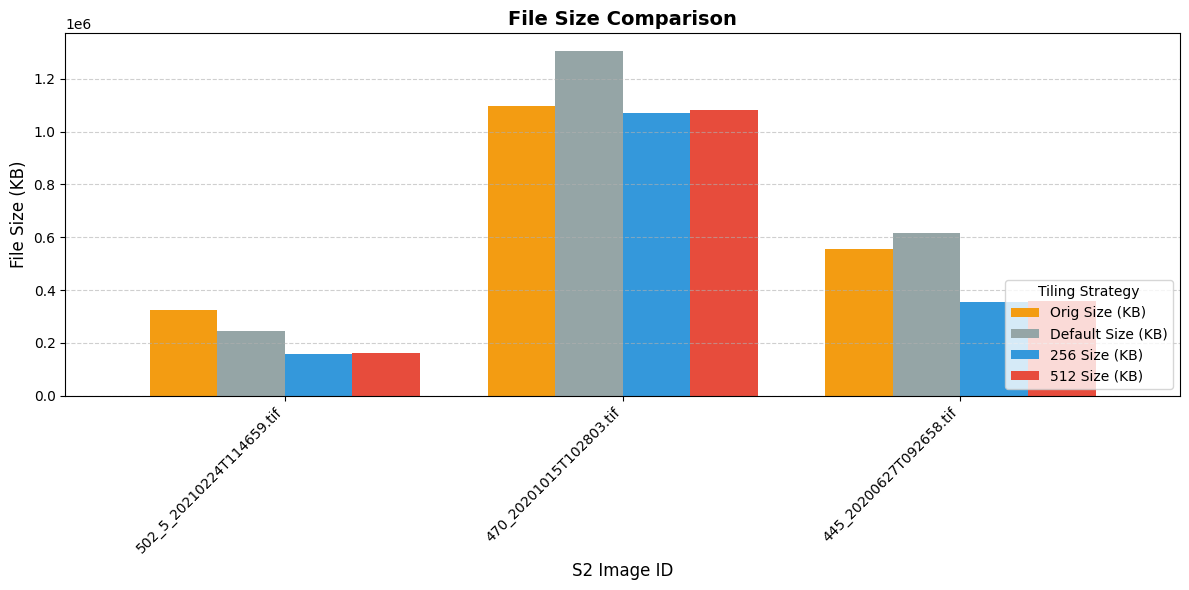


🎨 正在生成資源佔用圖表 (CPU & Memory)...


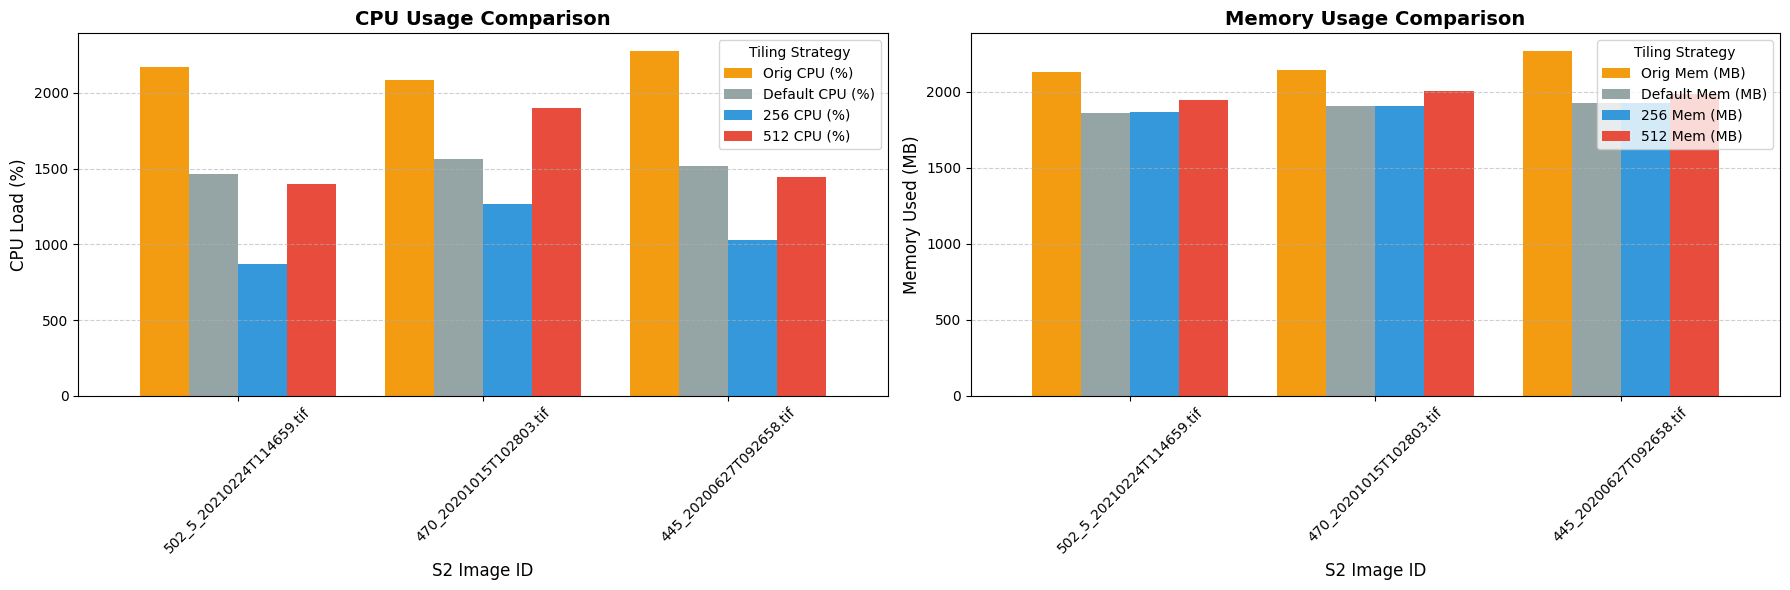

In [11]:
import os
import glob
import random
import time
import dask
from dask import delayed
import rasterio
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import timeit
from dask.diagnostics import ResourceProfiler

# 1️⃣ 設定資料夾路徑 (請依據你的實際路徑調整)
folder_path = "/home/chunen/nas/bigdata/final/S2_aoi_test"

# 尋找所有 tif 檔案
all_tifs = glob.glob(os.path.join(folder_path, "*.tif"))

# 過濾出「基準檔」(檔名開頭不是 Orig_, 256_, 512_ 的檔案)
files_default = [f for f in all_tifs if not os.path.basename(f).startswith(("Orig_", "256_", "512_"))]

# 測試參數設定
NUM_REQUESTS = 100       # 模擬 100 次 WebGIS 請求
REQUEST_SIZE = 256       # WebGIS 每次抓取的圖磚大小固定為 256x256

# 定義讀取單一 Window 的函數
def read_window(path, window):
    with rasterio.open(path) as src:
        data = src.read(window=window)
    return data.mean()

def bench(fn, n=5):
    times = []
    mems = []
    cpus = []
    for _ in range(n):
        # 設定 dt=0.05 意即每 50 毫秒採樣一次
        with ResourceProfiler(dt=0.05) as rprof:
            start_t = time.time()
            fn()
            end_t = time.time()
        times.append(end_t - start_t)
        
        if rprof.results:
            mems.append(max([r.mem for r in rprof.results]))
            cpus.append(max([r.cpu for r in rprof.results]))
        else:
            mems.append(0)
            cpus.append(0)
            
    return np.median(times), np.median(mems), np.median(cpus)

# 儲存結果的列表
results_data = []

print(f"🚀 開始模擬 WebGIS 隨機存取測試 (比較 Default vs 256 vs 512)...\n")

for path_default in files_default:
    base_name = os.path.basename(path_default)
    
    # 2️⃣ 組合出對應的 Orig, 256 與 512 檔案路徑
    path_orig = os.path.join(folder_path, f"Orig_{base_name}")
    path_256 = os.path.join(folder_path, f"256_deflate_{base_name}")
    path_512 = os.path.join(folder_path, f"512_deflate_{base_name}")
    
    # 確保四種檔案都齊全，否則跳過
    if not (os.path.exists(path_orig) and os.path.exists(path_256) and os.path.exists(path_512)):
        print(f"⚠️ 找不到 {base_name} 完整的配對檔案，跳過測試。")
        continue
        
    # 取得影像的長寬，以 Default 檔為準
    with rasterio.open(path_default) as src:
        img_width = src.width
        img_height = src.height
        
    # 調整請求視窗大小，若原圖比請求視窗還小，則取原圖大小
    req_w = min(img_width, REQUEST_SIZE)
    req_h = min(img_height, REQUEST_SIZE)
        
    # 3️⃣ 預先生成 100 個「隨機但固定」的 Window
    random_windows = []
    for _ in range(NUM_REQUESTS):
        xoff = random.randint(0, max(0, img_width - req_w))
        yoff = random.randint(0, max(0, img_height - req_h))
        win = rasterio.windows.Window(xoff, yoff, req_w, req_h)
        random_windows.append(win)

    # 測試 Orig 效能
    tasks_orig = [delayed(read_window)(path_orig, win) for win in random_windows]
    time_orig, mem_orig, cpu_orig = bench(lambda: dask.compute(*tasks_orig))

    # 4️⃣ 測試 GEE Default 效能
    tasks_def = [delayed(read_window)(path_default, win) for win in random_windows]
    time_def, mem_def, cpu_def = bench(lambda: dask.compute(*tasks_def))

    # 5️⃣ 測試 256_deflate 效能
    tasks_256 = [delayed(read_window)(path_256, win) for win in random_windows]
    time_256, mem_256, cpu_256 = bench(lambda: dask.compute(*tasks_256))

    # 6️⃣ 測試 512_deflate 效能
    tasks_512 = [delayed(read_window)(path_512, win) for win in random_windows]
    time_512, mem_512, cpu_512 = bench(lambda: dask.compute(*tasks_512))

    # 取得檔案大小 (轉換為 KB)
    sz_orig = round(os.path.getsize(path_orig) / 1024, 2)
    sz_def = round(os.path.getsize(path_default) / 1024, 2)
    sz_256 = round(os.path.getsize(path_256) / 1024, 2)
    sz_512 = round(os.path.getsize(path_512) / 1024, 2)

    # 判斷誰最快
    times = {"Orig": time_orig, "Default": time_def, "256": time_256, "512": time_512}
    winner = min(times, key=times.get)

    # 紀錄結果
    results_data.append({
        "Image_ID": base_name, 
        "Orig Size (KB)": sz_orig,
        "Default Size (KB)": sz_def,
        "256 Size (KB)": sz_256,
        "512 Size (KB)": sz_512,
        "Orig Latency (s)": round(time_orig, 3),
        "Default Latency (s)": round(time_def, 3),
        "256 Latency (s)": round(time_256, 3),
        "512 Latency (s)": round(time_512, 3),
        "Orig CPU (%)": round(cpu_orig, 1),
        "Default CPU (%)": round(cpu_def, 1),
        "256 CPU (%)": round(cpu_256, 1),
        "512 CPU (%)": round(cpu_512, 1),
        "Orig Mem (MB)": round(mem_orig, 1),
        "Default Mem (MB)": round(mem_def, 1),
        "256 Mem (MB)": round(mem_256, 1),
        "512 Mem (MB)": round(mem_512, 1),
        "Orig Throughput (req/s)": round(NUM_REQUESTS/time_orig, 3),
        "Default Throughput (req/s)": round(NUM_REQUESTS/time_def, 3),
        "256 Throughput (req/s)": round(NUM_REQUESTS/time_256, 3),
        "512 Throughput (req/s)": round(NUM_REQUESTS/time_512, 3),
        "Winner": winner
    })

    print(f"✅ 測試完成: {base_name}")

# 7️⃣ 輸出純文字報表 (改用 to_string 避開 tabulate 依賴)
df_results = pd.DataFrame(results_data)
print("\n📊 效能比較結果：")
print(df_results.to_string(index=False)) 

# 計算總體平均
print("💡 目前 DataFrame 擁有的欄位：", df_results.columns)
print("💡 資料總筆數：", len(df_results))
avg_orig = df_results["Orig Latency (s)"].mean()
avg_def = df_results["Default Latency (s)"].mean()
avg_256 = df_results["256 Latency (s)"].mean()
avg_512 = df_results["512 Latency (s)"].mean()

print("\n🏆 【總體平均延遲】")
print(f" - Orig 檔案   : {avg_orig:.3f} 秒")
print(f" - GEE Default : {avg_def:.3f} 秒")
print(f" - 256 策略    : {avg_256:.3f} 秒")
print(f" - 512 策略    : {avg_512:.3f} 秒")

avg_sz_orig = df_results["Orig Size (KB)"].mean()
avg_sz_def = df_results["Default Size (KB)"].mean()
avg_sz_256 = df_results["256 Size (KB)"].mean()
avg_sz_512 = df_results["512 Size (KB)"].mean()

print("\n📦 【總體平均檔案大小】")
print(f" - Orig 檔案   : {avg_sz_orig:.2f} KB")
print(f" - GEE Default : {avg_sz_def:.2f} KB")
print(f" - 256 策略    : {avg_sz_256:.2f} KB")
print(f" - 512 策略    : {avg_sz_512:.2f} KB")

avg_cpu_orig = df_results["Orig CPU (%)"].mean()
avg_cpu_def = df_results["Default CPU (%)"].mean()
avg_cpu_256 = df_results["256 CPU (%)"].mean()
avg_cpu_512 = df_results["512 CPU (%)"].mean()

avg_mem_orig = df_results["Orig Mem (MB)"].mean()
avg_mem_def = df_results["Default Mem (MB)"].mean()
avg_mem_256 = df_results["256 Mem (MB)"].mean()
avg_mem_512 = df_results["512 Mem (MB)"].mean()

print("\n🔥 【總體平均 CPU 負載】")
print(f" - Orig 檔案   : {avg_cpu_orig:.1f} %")
print(f" - GEE Default : {avg_cpu_def:.1f} %")
print(f" - 256 策略    : {avg_cpu_256:.1f} %")
print(f" - 512 策略    : {avg_cpu_512:.1f} %")

print("\n🧠 【總體平均記憶體佔用】")
print(f" - Orig 檔案   : {avg_mem_orig:.1f} MB")
print(f" - GEE Default : {avg_mem_def:.1f} MB")
print(f" - 256 策略    : {avg_mem_256:.1f} MB")
print(f" - 512 策略    : {avg_mem_512:.1f} MB")


# 8️⃣ 繪製視覺化柱狀圖 (Bar Chart)
print("\n🎨 正在生成柱狀圖...")

# 設定畫布大小
plt.figure(figsize=(12, 6))

# 使用 Pandas 內建的繪圖功能，將 Image_ID 當作 X 軸
# 選取我們要比較的三個時間欄位來畫群組柱狀圖 (Grouped Bar Chart)
ax = df_results.set_index("Image_ID")[["Orig Latency (s)", "Default Latency (s)", "256 Latency (s)", "512 Latency (s)"]].plot(
    kind="bar", 
    ax=plt.gca(), 
    width=0.8,
    color=["#f39c12", "#95a5a6", "#3498db", "#e74c3c"]  # 顏色：橘色(Orig)、灰色(Default)、藍色(256)、紅色(512)
)

# 圖表美化細節
plt.title("WebGIS Tile Request Latency Comparison (100 random requests)", fontsize=14, fontweight="bold")
plt.xlabel("S2 Image ID", fontsize=12)
plt.ylabel("Latency (Seconds)", fontsize=12)
plt.xticks(rotation=45, ha="right") # 讓 X 軸的檔名斜著放，避免擠在一起
plt.grid(axis="y", linestyle="--", alpha=0.6) # 加上水平輔助線方便對齊數值
plt.legend(title="Tiling Strategy", loc="lower right")

# 自動調整邊距並顯示
plt.tight_layout()
plt.show()

print("\n🎨 正在生成檔案容量柱狀圖...")
plt.figure(figsize=(12, 6))

ax_size = df_results.set_index("Image_ID")[["Orig Size (KB)", "Default Size (KB)", "256 Size (KB)", "512 Size (KB)"]].plot(
    kind="bar", 
    ax=plt.gca(), 
    width=0.8,
    color=["#f39c12", "#95a5a6", "#3498db", "#e74c3c"]
)

plt.title("File Size Comparison", fontsize=14, fontweight="bold")
plt.xlabel("S2 Image ID", fontsize=12)
plt.ylabel("File Size (KB)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(title="Tiling Strategy", loc="lower right")

plt.tight_layout()
plt.show()

print("\n🎨 正在生成資源佔用圖表 (CPU & Memory)...")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

df_results.set_index("Image_ID")[["Orig CPU (%)", "Default CPU (%)", "256 CPU (%)", "512 CPU (%)"]].plot(
    kind="bar", ax=axes[0], width=0.8, color=["#f39c12", "#95a5a6", "#3498db", "#e74c3c"]
)
axes[0].set_title("CPU Usage Comparison", fontsize=14, fontweight="bold")
axes[0].set_xlabel("S2 Image ID", fontsize=12)
axes[0].set_ylabel("CPU Load (%)", fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis="y", linestyle="--", alpha=0.6)
axes[0].legend(title="Tiling Strategy", loc="upper right")

df_results.set_index("Image_ID")[["Orig Mem (MB)", "Default Mem (MB)", "256 Mem (MB)", "512 Mem (MB)"]].plot(
    kind="bar", ax=axes[1], width=0.8, color=["#f39c12", "#95a5a6", "#3498db", "#e74c3c"]
)
axes[1].set_title("Memory Usage Comparison", fontsize=14, fontweight="bold")
axes[1].set_xlabel("S2 Image ID", fontsize=12)
axes[1].set_ylabel("Memory Used (MB)", fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis="y", linestyle="--", alpha=0.6)
axes[1].legend(title="Tiling Strategy", loc="upper right")

plt.tight_layout()
plt.show()


# 存csv
df_results.to_csv('/home/chunen/nas/bigdata/final/S2_aoi_test/S2_compare_pertif.csv', index=False)

#### COG and Zarr Comparison

🚀 開始模擬 WebGIS 隨機存取測試 (Orig vs Zarr 256 vs Zarr 512 vs COG 256)...

✅ 測試完成: 470_20200627T092658.tif
✅ 測試完成: 502_5_20210224T114659.tif
✅ 測試完成: 445_20200627T092658.tif

📊 效能比較結果：
                 Image_ID  Orig Size (KB)  Zarr 256 Size (KB)  Zarr 512 Size (KB)  COG 256 Size (KB)  Orig Latency (s)  Zarr 256 Latency (s)  Zarr 512 Latency (s)  COG 256 Latency (s)  Orig CPU (%)  Zarr 256 CPU (%)  Zarr 512 CPU (%)  COG 256 CPU (%)  Orig Mem (MB)  Zarr 256 Mem (MB)  Zarr 512 Mem (MB)  COG 256 Mem (MB)  Orig Throughput (req/s)  Zarr 256 Throughput (req/s)  Zarr 512 Throughput (req/s)  COG 256 Throughput (req/s)  Winner
  470_20200627T092658.tif      1098317.64           700755.87           699462.23         1069243.43             0.285                 0.243                 0.229                0.141        2086.6             987.5            1240.9           1265.2         2142.3             4551.5             4615.8            1904.6                  350.877                      412.200        

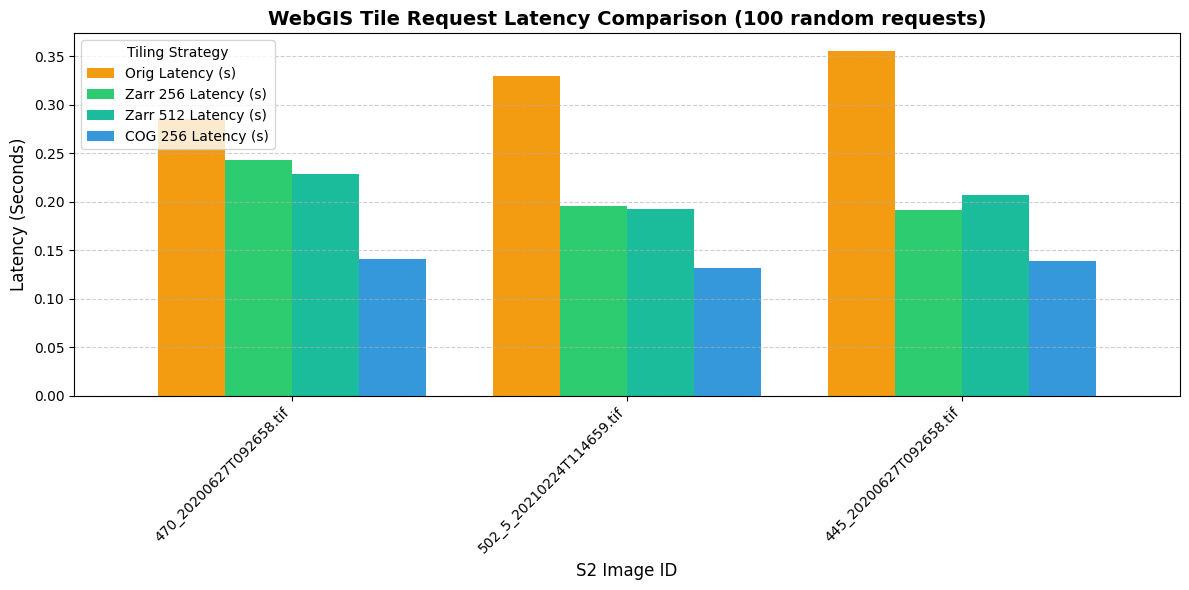


🎨 正在生成檔案容量柱狀圖...


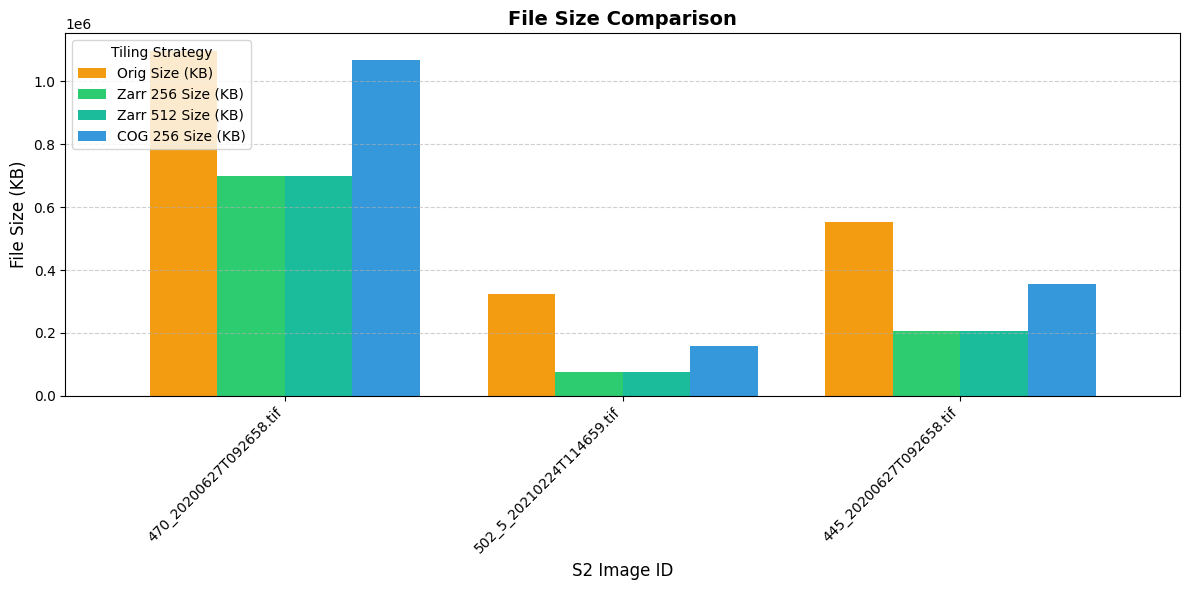


🎨 正在生成資源佔用圖表 (CPU & Memory)...


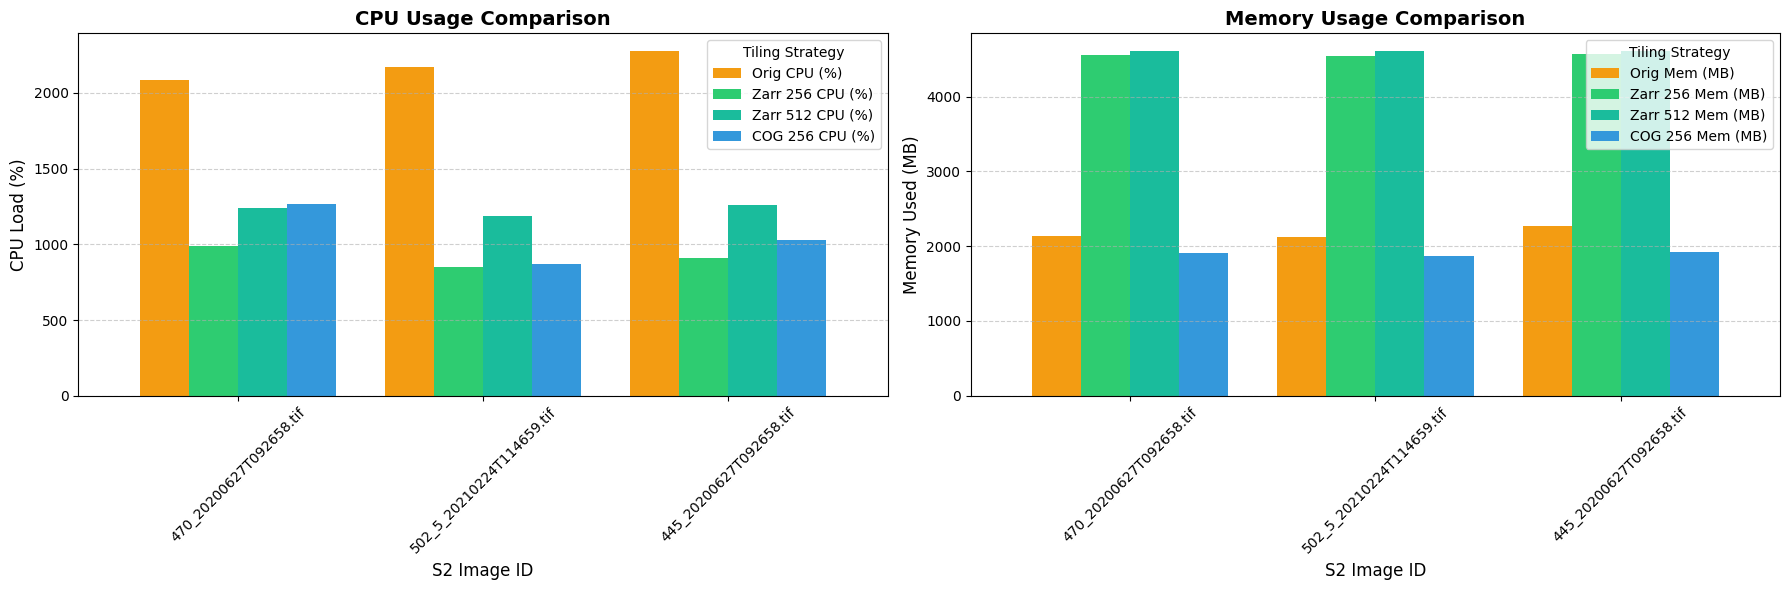


✅ 比較結果已儲存至: /home/chunen/nas/bigdata/final/S2_aoi_test_zarr/Zarr_vs_COG_compare.csv


In [ ]:
# Zarr跟COG比較
import os
import glob
import random
import time
import dask
from dask import delayed
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import zarr
from dask.diagnostics import ResourceProfiler

# 1️⃣ 設定資料夾與外部成績路徑
folder_path = "/home/chunen/nas/bigdata/final/S2_aoi_test_zarr"
csv_path = "/home/chunen/nas/bigdata/final/S2_aoi_test/S2_compare_pertif.csv"

# 載入歷史成績 (包含 Orig 與 COG 256)
df_history = pd.read_csv(csv_path)

# 尋找所有的 Zarr 256 檔案作為測試迴圈起點
files_zarr256 = glob.glob(os.path.join(folder_path, "256chunk_*.zarr"))

# 測試參數設定
NUM_REQUESTS = 100       # 模擬 100 次 WebGIS 請求
REQUEST_SIZE = 256       # WebGIS 每次抓取的圖磚大小固定為 256x256

# 計算資料夾大小 (針對 Zarr)
def get_dir_size(start_path):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(start_path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            if not os.path.islink(fp):
                total_size += os.path.getsize(fp)
    return total_size

# 定義讀取單一 Window 的函數 (給 Zarr 用)
def read_window_zarr(path, window_dict):
    col_off, row_off, width, height = window_dict['col_off'], window_dict['row_off'], window_dict['width'], window_dict['height']
    z = zarr.open(path, mode='r')
    arr = z['__xarray_dataarray_variable__']
    data = arr[:, row_off:row_off+height, col_off:col_off+width]
    return data.mean()

def bench(fn, n=5):
    times = []
    mems = []
    cpus = []
    for _ in range(n):
        with ResourceProfiler(dt=0.05) as rprof:
            start_t = time.time()
            fn()
            end_t = time.time()
        times.append(end_t - start_t)
        
        if rprof.results:
            mems.append(max([r.mem for r in rprof.results]))
            cpus.append(max([r.cpu for r in rprof.results]))
        else:
            mems.append(0)
            cpus.append(0)
            
    return np.median(times), np.median(mems), np.median(cpus)

# 儲存結果的列表
results_data = []

print(f"🚀 開始模擬 WebGIS 隨機存取測試 (Orig vs Zarr 256 vs Zarr 512 vs COG 256)...\n")

for path_zarr_256 in files_zarr256:
    # 從 256chunk_445_20200627T092658.zarr 萃取出 445_20200627T092658.tif 
    zarr_filename = os.path.basename(path_zarr_256)
    base_name = zarr_filename.replace("256chunk_", "").replace(".zarr", ".tif")
    
    # 組合出對應的 Zarr 512 檔案路徑
    zarr_base = base_name.replace(".tif", ".zarr")
    path_zarr_512 = os.path.join(folder_path, f"512chunk_{zarr_base}")
    
    # 確保 Zarr 檔案齊全，否則跳過
    if not os.path.exists(path_zarr_512):
        print(f"⚠️ 找不到 {base_name} 配對的 512chunk zarr 檔案，跳過測試。")
        continue

    # 從 CSV 中取得 Orig 與 COG 256 的成績 (改為匹配前綴 Event ID)
    event_id = base_name.split('_')[0]
    history_match = df_history[df_history['Image_ID'].str.startswith(f"{event_id}_")]
    
    if history_match.empty:
        print(f"⚠️ CSV 中找不到 ID 為 {event_id} 的歷史成績，跳過測試。")
        continue
    history_row = history_match.iloc[0]

    # 取得影像的長寬，以 Zarr 檔為準
    z_ref = zarr.open(path_zarr_256, mode='r')
    arr_ref = z_ref['__xarray_dataarray_variable__']
    img_height, img_width = arr_ref.shape[-2], arr_ref.shape[-1]
        
    # 調整請求視窗大小
    req_w = min(img_width, REQUEST_SIZE)
    req_h = min(img_height, REQUEST_SIZE)
        
    # 3️⃣ 預先生成 100 個「隨機但固定」的 Window (使用 dict 傳遞避免 rasterio window 依賴)
    random_windows = []
    for _ in range(NUM_REQUESTS):
        xoff = random.randint(0, max(0, img_width - req_w))
        yoff = random.randint(0, max(0, img_height - req_h))
        win = {'col_off': xoff, 'row_off': yoff, 'width': req_w, 'height': req_h}
        random_windows.append(win)

    # 5️⃣ 測試 Zarr 256 效能
    tasks_z256 = [delayed(read_window_zarr)(path_zarr_256, win) for win in random_windows]
    time_z256, mem_z256, cpu_z256 = bench(lambda: dask.compute(*tasks_z256))

    # 6️⃣ 測試 Zarr 512 效能
    tasks_z512 = [delayed(read_window_zarr)(path_zarr_512, win) for win in random_windows]
    time_z512, mem_z512, cpu_z512 = bench(lambda: dask.compute(*tasks_z512))

    # 從 CSV 中讀取歷史資料
    sz_orig = history_row["Orig Size (KB)"]
    time_orig = history_row["Orig Latency (s)"]
    cpu_orig = history_row["Orig CPU (%)"]
    mem_orig = history_row["Orig Mem (MB)"]

    sz_cog256 = history_row["256 Size (KB)"]
    time_cog256 = history_row["256 Latency (s)"]
    cpu_cog256 = history_row["256 CPU (%)"]
    mem_cog256 = history_row["256 Mem (MB)"]

    # 新測量 Zarr 檔案大小
    sz_z256 = round(get_dir_size(path_zarr_256) / 1024, 2)
    sz_z512 = round(get_dir_size(path_zarr_512) / 1024, 2)

    # 判斷誰最快
    times = {"Orig": time_orig, "Zarr 256": time_z256, "Zarr 512": time_z512, "COG 256": time_cog256}
    winner = min(times, key=times.get)

    # 紀錄結果
    results_data.append({
        "Image_ID": base_name, 
        "Orig Size (KB)": sz_orig,
        "Zarr 256 Size (KB)": sz_z256,
        "Zarr 512 Size (KB)": sz_z512,
        "COG 256 Size (KB)": sz_cog256,
        "Orig Latency (s)": round(time_orig, 3),
        "Zarr 256 Latency (s)": round(time_z256, 3),
        "Zarr 512 Latency (s)": round(time_z512, 3),
        "COG 256 Latency (s)": round(time_cog256, 3),
        "Orig CPU (%)": round(cpu_orig, 1),
        "Zarr 256 CPU (%)": round(cpu_z256, 1),
        "Zarr 512 CPU (%)": round(cpu_z512, 1),
        "COG 256 CPU (%)": round(cpu_cog256, 1),
        "Orig Mem (MB)": round(mem_orig, 1),
        "Zarr 256 Mem (MB)": round(mem_z256, 1),
        "Zarr 512 Mem (MB)": round(mem_z512, 1),
        "COG 256 Mem (MB)": round(mem_cog256, 1),
        "Orig Throughput (req/s)": round(NUM_REQUESTS/time_orig, 3),
        "Zarr 256 Throughput (req/s)": round(NUM_REQUESTS/time_z256, 3),
        "Zarr 512 Throughput (req/s)": round(NUM_REQUESTS/time_z512, 3),
        "COG 256 Throughput (req/s)": round(NUM_REQUESTS/time_cog256, 3),
        "Winner": winner
    })

    print(f"✅ 測試完成: {base_name}")

# 7️⃣ 輸出純文字報表
df_results = pd.DataFrame(results_data)
print("\n📊 效能比較結果：")
print(df_results.to_string(index=False)) 

# 計算總體平均
avg_orig = df_results["Orig Latency (s)"].mean()
avg_z256 = df_results["Zarr 256 Latency (s)"].mean()
avg_z512 = df_results["Zarr 512 Latency (s)"].mean()
avg_c256 = df_results["COG 256 Latency (s)"].mean()

print("\n🏆 【總體平均延遲】")
print(f" - Orig 檔案   : {avg_orig:.3f} 秒")
print(f" - Zarr 256 策略: {avg_z256:.3f} 秒")
print(f" - Zarr 512 策略: {avg_z512:.3f} 秒")
print(f" - COG 256 策略: {avg_c256:.3f} 秒")

avg_sz_orig = df_results["Orig Size (KB)"].mean()
avg_sz_z256 = df_results["Zarr 256 Size (KB)"].mean()
avg_sz_z512 = df_results["Zarr 512 Size (KB)"].mean()
avg_sz_c256 = df_results["COG 256 Size (KB)"].mean()

print("\n📦 【總體平均檔案大小】")
print(f" - Orig 檔案   : {avg_sz_orig:.2f} KB")
print(f" - Zarr 256 策略: {avg_sz_z256:.2f} KB")
print(f" - Zarr 512 策略: {avg_sz_z512:.2f} KB")
print(f" - COG 256 策略: {avg_sz_c256:.2f} KB")

avg_cpu_orig = df_results["Orig CPU (%)"].mean()
avg_cpu_z256 = df_results["Zarr 256 CPU (%)"].mean()
avg_cpu_z512 = df_results["Zarr 512 CPU (%)"].mean()
avg_cpu_c256 = df_results["COG 256 CPU (%)"].mean()

avg_mem_orig = df_results["Orig Mem (MB)"].mean()
avg_mem_z256 = df_results["Zarr 256 Mem (MB)"].mean()
avg_mem_z512 = df_results["Zarr 512 Mem (MB)"].mean()
avg_mem_c256 = df_results["COG 256 Mem (MB)"].mean()

print("\n🔥 【總體平均 CPU 負載】")
print(f" - Orig 檔案   : {avg_cpu_orig:.1f} %")
print(f" - Zarr 256 策略: {avg_cpu_z256:.1f} %")
print(f" - Zarr 512 策略: {avg_cpu_z512:.1f} %")
print(f" - COG 256 策略: {avg_cpu_c256:.1f} %")

print("\n🧠 【總體平均記憶體佔用】")
print(f" - Orig 檔案   : {avg_mem_orig:.1f} MB")
print(f" - Zarr 256 策略: {avg_mem_z256:.1f} MB")
print(f" - Zarr 512 策略: {avg_mem_z512:.1f} MB")
print(f" - COG 256 策略: {avg_mem_c256:.1f} MB")

# 8️⃣ 繪製視覺化圖表
print("\n🎨 正在生成柱狀圖...")

plt.figure(figsize=(12, 6))
ax = df_results.set_index("Image_ID")[["Orig Latency (s)", "Zarr 256 Latency (s)", "Zarr 512 Latency (s)", "COG 256 Latency (s)"]].plot(
    kind="bar", ax=plt.gca(), width=0.8,
    color=["#f39c12", "#2ecc71", "#1abc9c", "#3498db"]  # 橘色, 淺綠, 深綠, 藍色
)
plt.title("WebGIS Tile Request Latency Comparison (100 random requests)", fontsize=14, fontweight="bold")
plt.xlabel("S2 Image ID", fontsize=12)
plt.ylabel("Latency (Seconds)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(title="Tiling Strategy", loc="upper left")
plt.tight_layout()
plt.show()

print("\n🎨 正在生成檔案容量柱狀圖...")
plt.figure(figsize=(12, 6))
ax_size = df_results.set_index("Image_ID")[["Orig Size (KB)", "Zarr 256 Size (KB)", "Zarr 512 Size (KB)", "COG 256 Size (KB)"]].plot(
    kind="bar", ax=plt.gca(), width=0.8,
    color=["#f39c12", "#2ecc71", "#1abc9c", "#3498db"]
)
plt.title("File Size Comparison", fontsize=14, fontweight="bold")
plt.xlabel("S2 Image ID", fontsize=12)
plt.ylabel("File Size (KB)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(title="Tiling Strategy", loc="upper left")
plt.tight_layout()
plt.show()

print("\n🎨 正在生成資源佔用圖表 (CPU & Memory)...")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

df_results.set_index("Image_ID")[["Orig CPU (%)", "Zarr 256 CPU (%)", "Zarr 512 CPU (%)", "COG 256 CPU (%)"]].plot(
    kind="bar", ax=axes[0], width=0.8, color=["#f39c12", "#2ecc71", "#1abc9c", "#3498db"]
)
axes[0].set_title("CPU Usage Comparison", fontsize=14, fontweight="bold")
axes[0].set_xlabel("S2 Image ID", fontsize=12)
axes[0].set_ylabel("CPU Load (%)", fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis="y", linestyle="--", alpha=0.6)
axes[0].legend(title="Tiling Strategy", loc="upper right")

df_results.set_index("Image_ID")[["Orig Mem (MB)", "Zarr 256 Mem (MB)", "Zarr 512 Mem (MB)", "COG 256 Mem (MB)"]].plot(
    kind="bar", ax=axes[1], width=0.8, color=["#f39c12", "#2ecc71", "#1abc9c", "#3498db"]
)
axes[1].set_title("Memory Usage Comparison", fontsize=14, fontweight="bold")
axes[1].set_xlabel("S2 Image ID", fontsize=12)
axes[1].set_ylabel("Memory Used (MB)", fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis="y", linestyle="--", alpha=0.6)
axes[1].legend(title="Tiling Strategy", loc="upper right")

plt.tight_layout()
plt.show()

# 存csv
out_csv = '/home/chunen/nas/bigdata/final/S2_aoi_test_zarr/Zarr_vs_COG_compare.csv'
df_results.to_csv(out_csv, index=False)
print(f"\n✅ 比較結果已儲存至: {out_csv}")